In [ ]:
Dərs Sonu İmtahanı

In [ ]:
Siz Data Analitik olaraq işə başlamısınız. Və sizə 1901-2022 arasında Nobel laureatı olmuş şəxslər haqqında data verilib. Data ilə tanış olun. Rəhbərlik aşağıdakı tapşırıqlar vasitəsilə hazırlayacağınız bir hesabat istəyir:


In [1]:
import pandas as pd
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\nobel_latest.csv")
print(df.head())

   Year  Laureate_Id       Firstname     Lastname    Category Gender  \
0  1901            1  Wilhelm Conrad      Röntgen     physics   male   
1  1901          293            Emil  von Behring    medicine   male   
2  1901          462           Henry       Dunant       peace   male   
3  1901          463        Frédéric        Passy       peace   male   
4  1901          569           Sully    Prudhomme  literature   male   

   Prize_Share                                         Motivation  Birth_Date  \
0            1  "in recognition of the extraordinary services ...  1845-03-27   
1            1  "for his work on serum therapy especially its ...  1854-03-15   
2            2  "for his humanitarian efforts to help wounded ...  1828-05-08   
3            2  "for his lifelong work for international peace...  1822-05-20   
4            1  "in special recognition of his poetic composit...  1839-03-16   

           Birth_Country              Birth_City Birth_Country_Code  \
0  Prussi

In [ ]:
1.

In [ ]:
(5) / Datada cəmi neçə laureat verilib?

In [ ]:
df["Laureate_Id"].nunique()

In [ ]:
2.

In [ ]:
(10) / Ən çox hansı ildə Nobel laureatı verilib? Top 10 tapın və barchart vasitəsilə vizuallaşdırın.

In [ ]:
import matplotlib.pyplot as plt
top10_years = (
    df["Year"]
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top10_years.plot(kind="bar")
plt.title("Top 10 İldə Ən Çox Nobel Laureatı")
plt.xlabel("İl")
plt.ylabel("Laureat Sayı")
plt.xticks(rotation=45)
plt.show()

In [ ]:
3.

In [ ]:
(10) / Birdən çox Nobel laureatı olan adam və ya topluluq var? Onlar neçə nəfərdirlər? Ən çox alan kimdir və neçə laureat alıb?


In [2]:
person_counts = (
    df.groupby(["Laureate_Id", "Firstname", "Lastname"])
      .size()
      .reset_index(name="Nobel_Count")
)

multi_winners = person_counts[person_counts["Nobel_Count"] > 1]
print("Birdən çox Nobel alanların sayı:")
print(len(multi_winners))
print("\nOnlar:")
print(multi_winners)
top_person = person_counts.sort_values("Nobel_Count", ascending=False).head(1)
print("\nƏn çox Nobel alan şəxs:")
print(top_person)

Birdən çox Nobel alanların sayı:
5

Onlar:
     Laureate_Id  Firstname   Lastname  Nobel_Count
5              6      Marie      Curie            2
64            66       John    Bardeen            2
212          217      Linus    Pauling            2
217          222  Frederick     Sanger            2
702          743      Barry  Sharpless            2

Ən çox Nobel alan şəxs:
    Laureate_Id Firstname Lastname  Nobel_Count
64           66      John  Bardeen            2


In [ ]:
4.

In [ ]:
(15) / Hansı kateqoriya üzrə laureatlar neçə dənədir? Bunu vizuallaşdırın, amma bu vizuala eyni zamanda bir məlumatda əlavə edin – Gender. Yəni hansı kateqoriya üzrə hansı gender nümayəndələri nə qədər laureata layiq görülüblər? Eyni zamanda bu pivotlaşdırmanı (qruplaşdırma) kodla da həyata keçirin.


Pivot Table:
Gender      female  male  org
Category                     
chemistry        8   183    0
economics        2    90    0
literature      17   102    0
medicine        12   213    0
peace           18    92   30
physics          4   218    0


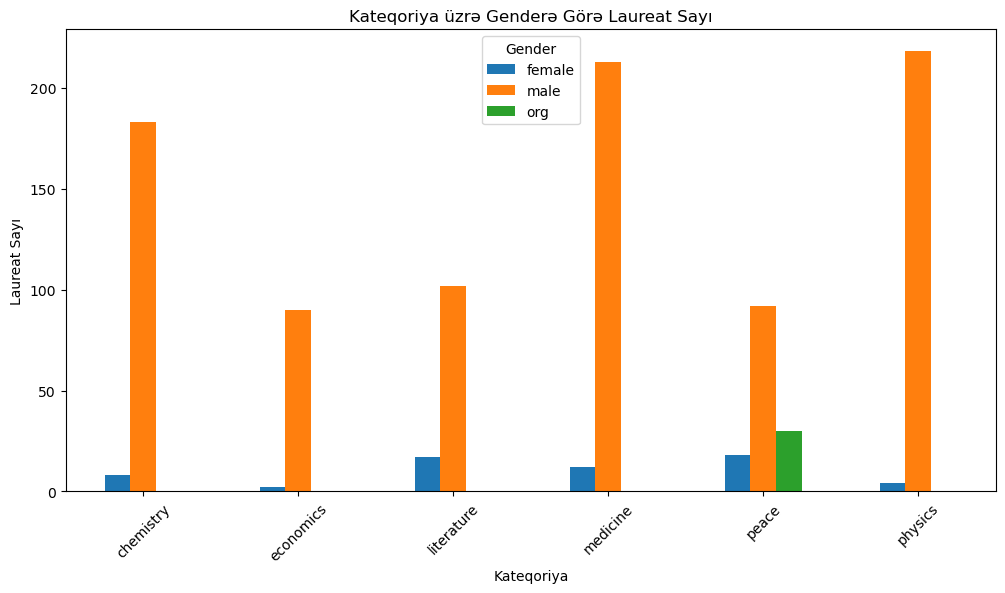

In [4]:
import matplotlib.pyplot as plt
pivot_table = pd.pivot_table(
    df,
    values="Laureate_Id",
    index="Category",
    columns="Gender",
    aggfunc="count",
    fill_value=0
)
print("Pivot Table:")
print(pivot_table)

pivot_table.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Kateqoriya üzrə Genderə Görə Laureat Sayı")
plt.xlabel("Kateqoriya")
plt.ylabel("Laureat Sayı")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.show()

In [ ]:
5.

In [ ]:
(5) / Kişilər/qadınlar/topluluqlar olaraq ortalama neçə nəfər laureat alırlar? (Prize_Share). 

In [5]:
df["Prize_Share"] = pd.to_numeric(df["Prize_Share"], errors="coerce")
gender_avg = (
    df[df["Gender"] != ""]
    .groupby("Gender")["Prize_Share"]
    .mean()
)
print("Gender üzrə ortalama Prize_Share:")
print(gender_avg)
group_avg = (
    df[df["Organization_Name"] != ""]
    ["Prize_Share"]
    .mean()
)
print("\nTopluluqlar üzrə ortalama Prize_Share:")
print(group_avg)

Gender üzrə ortalama Prize_Share:
Gender
female    1.983607
male      2.045657
org       1.466667
Name: Prize_Share, dtype: float64

Topluluqlar üzrə ortalama Prize_Share:
2.024266936299292


In [ ]:
6.

In [ ]:
(10) / Motivation sütununda dırnaq işarələrini yığışdıran kodu yazın.

In [6]:
df["Motivation"] = df["Motivation"].str.replace('"', '', regex=False)
print(df["Motivation"].head())

0    in recognition of the extraordinary services h...
1    for his work on serum therapy especially its a...
2    for his humanitarian efforts to help wounded s...
3    for his lifelong work for international peace ...
4    in special recognition of his poetic compositi...
Name: Motivation, dtype: object


In [ ]:
7.

In [ ]:
(20) / Birth_Date sütununda laureatların doğum tarixləri verilmişdir. Həmin sütunu ayıraraq, yeni bir sütun yaradın (Birth_year adında). Ən çox hansı əsrdə doğulan elm adamları bu ödülü aldığını göstərən kodları yazın.


In [7]:
df["Birth_Date"] = pd.to_datetime(df["Birth_Date"], errors="coerce")
df["Birth_year"] = df["Birth_Date"].dt.year
print("Yeni sütun:")
print(df[["Birth_Date", "Birth_year"]].head())
df["Century"] = (df["Birth_year"] // 100) + 1
print("\nƏsrlər üzrə say:")
century_counts = df["Century"].value_counts().sort_values(ascending=False)
print(century_counts)
most_common_century = century_counts.head(1)
print("\nƏn çox Nobel alanların doğulduğu əsr:")
print(most_common_century)

Yeni sütun:
  Birth_Date  Birth_year
0 1845-03-27      1845.0
1 1854-03-15      1854.0
2 1828-05-08      1828.0
3 1822-05-20      1822.0
4 1839-03-16      1839.0

Əsrlər üzrə say:
Century
19.0    286
Name: count, dtype: int64

Ən çox Nobel alanların doğulduğu əsr:
Century
19.0    286
Name: count, dtype: int64


In [ ]:
8.

In [ ]:
(10) / Laureata layiq görülən əməkdaşlar ən çox hansı ölkədən olub? Bu məlumatı vizuallaşdırın.

Top 10 ölkə:
Birth_Country
USA                289
United Kingdom      90
Germany             67
France              56
Sweden              30
Japan               28
Canada              21
Switzerland         19
the Netherlands     19
Russia              18
Name: count, dtype: int64


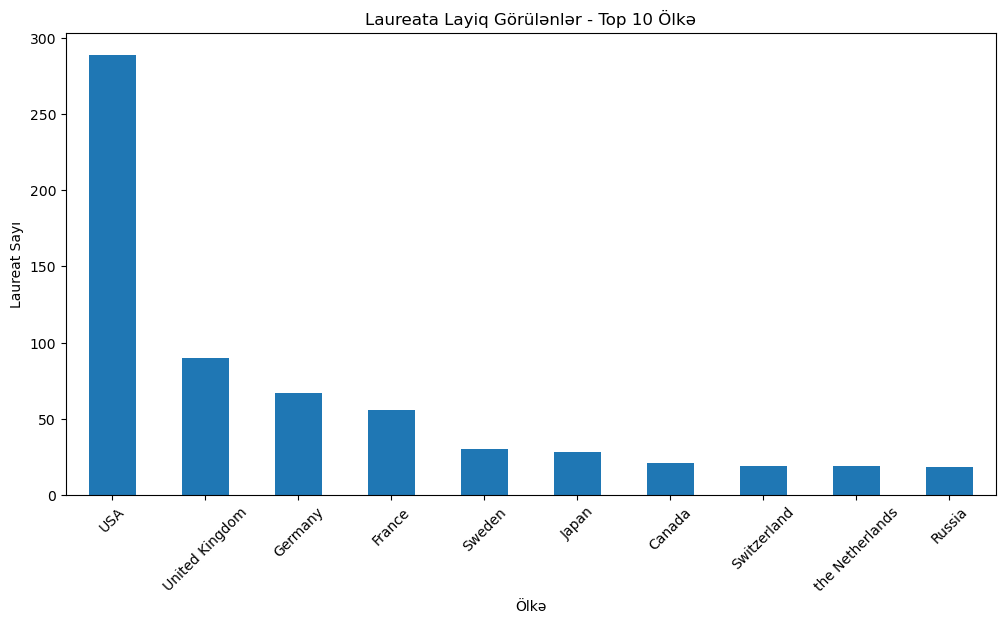

In [8]:
# Top 10 ölkə üzrə etdim.
country_counts = (
    df["Birth_Country"]
    .value_counts()
    .head(10)   
)
print("Top 10 ölkə:")
print(country_counts)

plt.figure(figsize=(12,6))
country_counts.plot(kind="bar")
plt.title("Laureata Layiq Görülənlər - Top 10 Ölkə")
plt.xlabel("Ölkə")
plt.ylabel("Laureat Sayı")
plt.xticks(rotation=45)
plt.show()

In [ ]:
9.

In [ ]:
(15) / Death_date sütununda elm adamlarının öldüyü tarixi göstərir. Əgər bir elm adamı deyil topluluqdursa, Death_date “0000-00-00” kimi göstərir. Əgər elm adamıdırsa, və “0000-00-00” kimi görünürsə, deməli adam hələ də yaşayır. İndi sizdən istənilən məlumat, neçə nəfər laureat ölüb və neçəsi hələ də yaşayır? org gender-a sahib sətrlər sayılmamalıdır.


In [9]:
people = df[df["Gender"] != ""]
dead = people[people["Death_Date"] != "0000-00-00"]
alive = people[people["Death_Date"] == "0000-00-00"]
print("Ölmüş laureatlar sayı:", len(dead))
print("Hələ yaşayan laureatlar sayı:", len(alive))

Ölmüş laureatlar sayı: 659
Hələ yaşayan laureatlar sayı: 330


In [ ]:
Bonus (10): Yeni bir sütun yaradın və adı Organization_type olsun. Bu sütunu Organization_name sütununda olan məlumatlara görə doldurun. Əgər organization_name-də hər hansı bir yerdə university görsə, həmin sütuna “University” yazsın. Qalan hər şeyə “Others” yazsın. Və daha sonra bu sütunu qruplaşdırın və neçə universitetin bu laureatı qazandığını tapın (tips: str.contains( )) 


In [10]:
df["Organization_type"] = df["Organization_Name"].str.contains(
    "university",
    case=False,
    na=False
).map({True: "University", False: "Others"})
print(df[["Organization_Name", "Organization_type"]].head())
result = df.groupby("Organization_type")["Laureate_Id"].count()
print("\nQruplaşdırma nəticəsi:")
print(result)

    Organization_Name Organization_type
0   Munich University        University
1  Marburg University        University
2                 NaN            Others
3                 NaN            Others
4                 NaN            Others

Qruplaşdırma nəticəsi:
Organization_type
Others        542
University    447
Name: Laureate_Id, dtype: int64


In [ ]:
Bonus (10): Hazırladığınız vizuallardan (maks 4) bir dashboard düzəldin. 4 hissədən ibarət olsun.


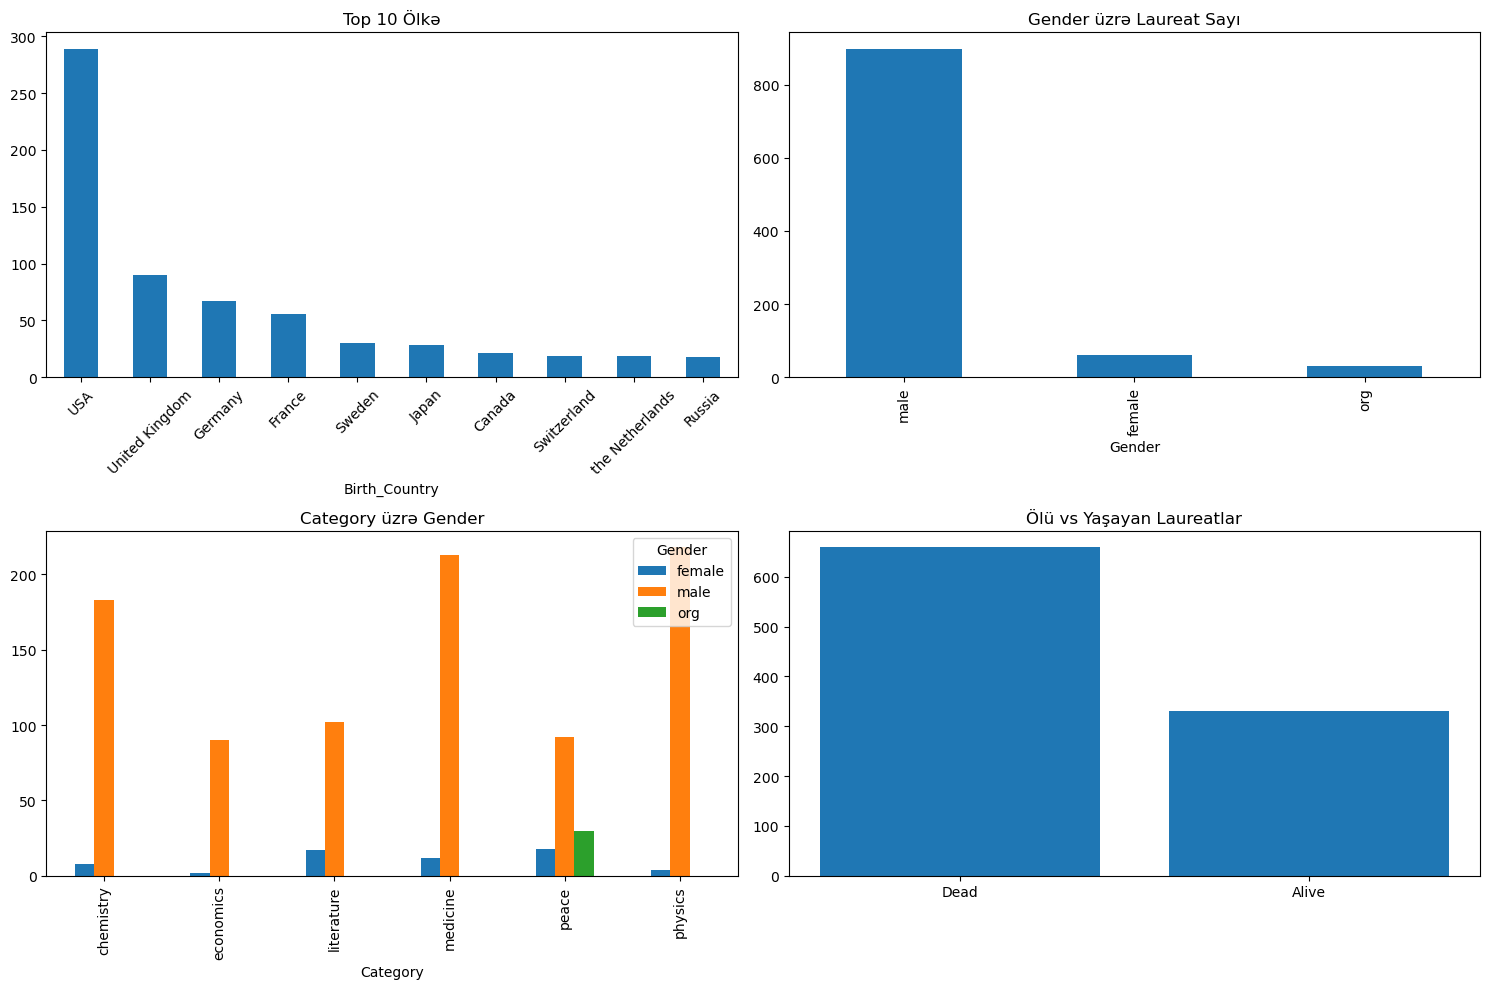

In [11]:
# Top 10 ölkə
top_countries = df["Birth_Country"].value_counts().head(10)

# Gender üzrə say
gender_counts = df[df["Gender"] != "" ]["Gender"].value_counts()

# Ölü və yaşayanlar
people = df[df["Gender"] != ""]
dead = people[people["Death_Date"] != "0000-00-00"].shape[0]
alive = people[people["Death_Date"] == "0000-00-00"].shape[0]

# Category üzrə gender pivot
pivot = pd.pivot_table(
    df,
    values="Laureate_Id",
    index="Category",
    columns="Gender",
    aggfunc="count",
    fill_value=0
)

# DASHBOARD

fig, axes = plt.subplots(2, 2, figsize=(15,10))

# Top 10 ölkə
top_countries.plot(kind="bar", ax=axes[0,0])
axes[0,0].set_title("Top 10 Ölkə")
axes[0,0].tick_params(axis='x', rotation=45)

# Gender üzrə say
gender_counts.plot(kind="bar", ax=axes[0,1])
axes[0,1].set_title("Gender üzrə Laureat Sayı")

# Category üzrə gender pivot
pivot.plot(kind="bar", ax=axes[1,0])
axes[1,0].set_title("Category üzrə Gender")

# Ölü və yaşayanlar
axes[1,1].bar(["Dead","Alive"], [dead, alive])
axes[1,1].set_title("Ölü vs Yaşayan Laureatlar")
plt.tight_layout()
plt.show()